## Import required libraries (including AQMS_Utils & AQMS_Utils_Xtra)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import AQMS_Utils as aqms
import AQMS_Utils_Xtra as aqmsx
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the fx futures returns

In [2]:
# Read the .csv file of rolled futures returns
fx_returns = pd.read_csv('g10_rolled_futures_returns.csv')
fx_returns = fx_returns.set_index(['Date'])
fx_returns.index = pd.to_datetime(fx_returns.index)
# Relabel the columns with FX codes
fx_returns.columns = ['EUR', 'JPY', 'GBP', 'AUD', 'NZD', 'CAD', 'CHF', 'NOK', 'SEK']

In [3]:
fx_returns.head()

,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
Date,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,0.002224,-0.017515,-0.001343,-0.009103,-0.007619,-0.004628,0.002321,NaN,NaN
2000-01-05,0.001641,-0.011092,0.002928,0.003499,-0.005753,0.002461,0.001698,NaN,NaN
2000-01-06,-0.001931,-0.010903,0.003405,-0.004109,-0.005786,-0.007547,-0.001544,NaN,NaN
2000-01-07,-0.001644,0.001878,-0.005477,0.000610,0.000000,0.002183,-0.005112,NaN,NaN


## NOK and SEK start in 2008. Need to fill them with a proxy. Lets try downloading spot prices from investing.com

In [4]:
# Using investing.com rates
df = pd.read_csv('NOK to USD Historical Exchage Rates.csv', parse_dates=['Date'], dayfirst=True)
# Set 'Date' as the datetime index and keep only the 'Price' column
df = df.set_index('Date')[['Price']]
df.columns = ['NOK_SPOT']
df.index = pd.to_datetime(df.index)
# Sort the DataFrame by Date in ascending order
df = df.sort_index()
nok = aqms.calc_log_returns(df)

df = pd.read_csv('SEK to USD Historical Exchage Rates.csv', parse_dates=['Date'], dayfirst=True)
# Set 'Date' as the datetime index and keep only the 'Price' column
df = df.set_index('Date')[['Price']]
df.columns = ['SEK_SPOT']
df.index = pd.to_datetime(df.index)
# Sort the DataFrame by Date in ascending order
df = df.sort_index()
sek = aqms.calc_log_returns(df)

# Lets plot the correlations for the overlapping period (2009-2019)
pd.concat([fx_returns['NOK'],fx_returns['SEK'], nok, sek], axis = 1).dropna().corr()

,NOK,SEK,NOK_SPOT,SEK_SPOT
NOK,1.000000,0.770484,0.908986,0.726488
SEK,0.770484,1.000000,0.718491,0.880939
NOK_SPOT,0.908986,0.718491,1.000000,0.786076
SEK_SPOT,0.726488,0.880939,0.786076,1.000000


## Hmmm. The correlation is about 0.9. Lets take a look at the data visually.

<Axes: xlabel='Date', ylabel='cumsum rtns %'>

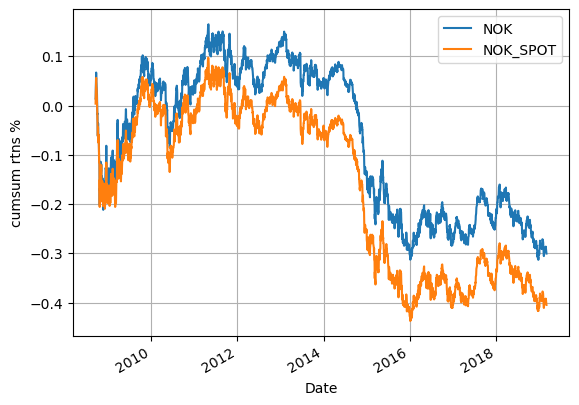

In [5]:
pd.concat([fx_returns['NOK'], nok], axis = 1).dropna().cumsum().plot(grid = True, ylabel = 'cumsum rtns %')

<Axes: xlabel='Date', ylabel='cumsum rtns %'>

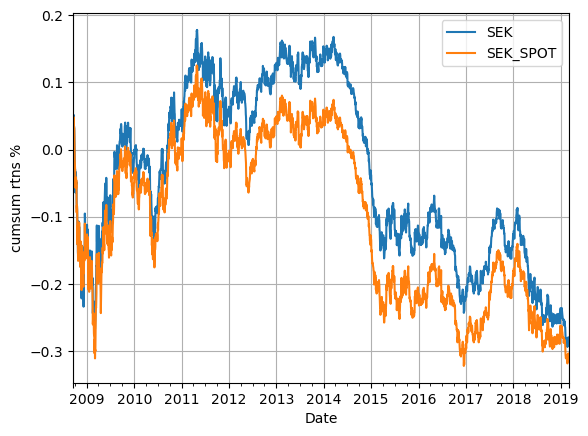

In [6]:
pd.concat([fx_returns['SEK'], sek], axis = 1).dropna().cumsum().plot(grid = True, ylabel = 'cumsum rtns %')

## There seems to be a discrepency between the spot returns and the futures returns. Ahhh, interest rate differentials! Let me try and source some forward rates instead to better match the futures series

In [7]:
import pickle
# Load Bloomberg data for 1-3 M forward rates (thank you Rishi!)
with open('noksek_fwds', 'rb') as file: 
    noksek_fwds = pickle.load(file) 
noksek_fwds.ffill(inplace = True)

In [8]:
noksek_fwds.head()

,USDSEK_1M_fwd,USDNOK_1M_fwd,USDSEK_2M_fwd,USDNOK_2M_fwd,USDSEK_3M_fwd,USDNOK_3M_fwd
Date,,,,,,
2000-01-03,8.35865,7.88740,8.34250,7.88675,8.32520,7.88455
2000-01-04,8.36375,7.94405,8.34750,7.94490,8.33060,7.94265
2000-01-05,8.35045,7.94220,8.33415,7.94025,8.31700,7.93860
2000-01-06,8.35495,7.94125,8.33885,7.93925,8.32140,7.93775
2000-01-07,8.39965,7.97355,8.38230,7.97225,8.36625,7.97025


## Lets do the same things and look at overlapping correlations and graphs. Lets use the 2M forward as it probably best represts a 3M future as it trades to expiry. 

In [9]:
nok_fwd = 1 / noksek_fwds['USDNOK_2M_fwd'].to_frame()
nok_fwd.columns = ['NOK_2M_FWD']
nok_fwd = aqms.calc_log_returns(nok_fwd)
sek_fwd = 1 / noksek_fwds['USDSEK_2M_fwd'].to_frame()
sek_fwd.columns = ['SEK_2M_FWD']
sek_fwd = aqms.calc_log_returns(sek_fwd)
pd.concat([fx_returns['NOK'],fx_returns['SEK'], nok_fwd, sek_fwd], axis = 1).dropna().corr()

,NOK,SEK,NOK_2M_FWD,SEK_2M_FWD
NOK,1.000000,0.768719,0.925080,0.725049
SEK,0.768719,1.000000,0.718465,0.898955
NOK_2M_FWD,0.925080,0.718465,1.000000,0.782306
SEK_2M_FWD,0.725049,0.898955,0.782306,1.000000


<Axes: xlabel='Date', ylabel='cumsum rtns %'>

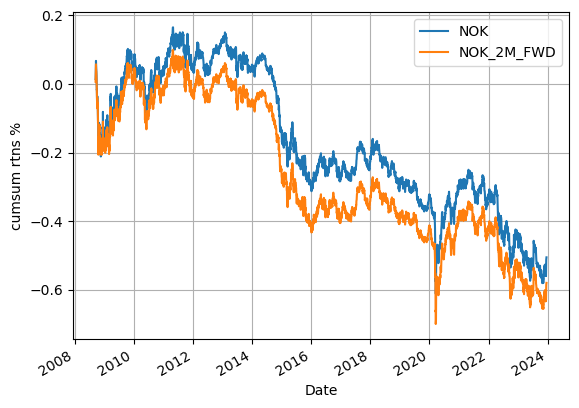

In [10]:
pd.concat([fx_returns['NOK'], nok_fwd], axis = 1).dropna().cumsum().plot(grid = True, ylabel = 'cumsum rtns %')

<Axes: xlabel='Date', ylabel='cumsum rtns %'>

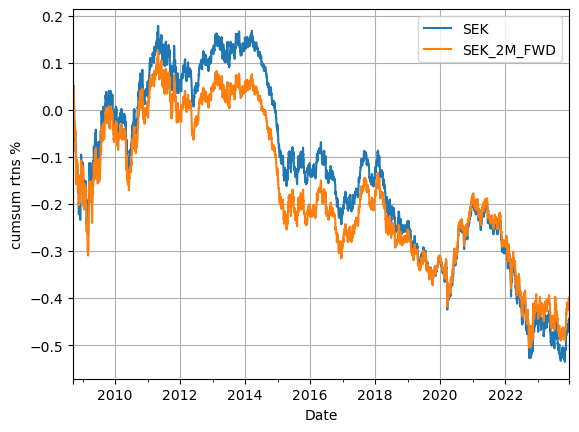

In [11]:
pd.concat([fx_returns['SEK'], sek_fwd], axis = 1).dropna().cumsum().plot(grid = True, ylabel = 'cumsum rtns %')

## That looks better! We will use the Bloomberg 2M forward rates as a proxy

In [12]:
fx_returns['NOK'] = fx_returns['NOK'].fillna(nok_fwd['NOK_2M_FWD'])
fx_returns['SEK'] = fx_returns['SEK'].fillna(sek_fwd['SEK_2M_FWD'])

In [13]:
fx_returns

,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
Date,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,0.002224,-0.017515,-0.001343,-0.009103,-0.007619,-0.004628,0.002321,-0.007346,-0.000599
2000-01-05,0.001641,-0.011092,0.002928,0.003499,-0.005753,0.002461,0.001698,0.000585,0.001601
2000-01-06,-0.001931,-0.010903,0.003405,-0.004109,-0.005786,-0.007547,-0.001544,0.000126,-0.000564
2000-01-07,-0.001644,0.001878,-0.005477,0.000610,0.000000,0.002183,-0.005112,-0.004148,-0.005197
...,...,...,...,...,...,...,...,...,...
2024-12-11,-0.003377,-0.004794,-0.002273,-0.001725,-0.002675,0.000212,-0.002341,0.000245,-0.000623
2024-12-12,-0.001908,0.000305,-0.005902,-0.001099,-0.003376,-0.003404,-0.007679,-0.002426,-0.003662
2024-12-13,0.002003,-0.007731,-0.004271,-0.001101,-0.001649,-0.001777,-0.001650,0.002824,0.003495


## Note NaNs at top and bottom of data. Lets get rid of those

In [14]:
fx_returns.drop(fx_returns.head(1).index,inplace=True)
fx_returns.drop(fx_returns.tail(1).index,inplace=True)
fx_returns

,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
Date,,,,,,,,,
2000-01-04,0.002224,-0.017515,-0.001343,-0.009103,-0.007619,-0.004628,0.002321,-0.007346,-0.000599
2000-01-05,0.001641,-0.011092,0.002928,0.003499,-0.005753,0.002461,0.001698,0.000585,0.001601
2000-01-06,-0.001931,-0.010903,0.003405,-0.004109,-0.005786,-0.007547,-0.001544,0.000126,-0.000564
2000-01-07,-0.001644,0.001878,-0.005477,0.000610,0.000000,0.002183,-0.005112,-0.004148,-0.005197
2000-01-10,-0.002714,0.001042,-0.001099,0.001371,-0.001936,0.000581,-0.002799,-0.004668,-0.003792
...,...,...,...,...,...,...,...,...,...
2024-12-10,-0.002703,-0.004544,0.001724,-0.009746,-0.011568,-0.000354,-0.004797,-0.002467,-0.005243
2024-12-11,-0.003377,-0.004794,-0.002273,-0.001725,-0.002675,0.000212,-0.002341,0.000245,-0.000623
2024-12-12,-0.001908,0.000305,-0.005902,-0.001099,-0.003376,-0.003404,-0.007679,-0.002426,-0.003662


In [15]:
fx_returns.describe()

,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
count,6510.000000,6510.000000,6510.000000,6510.000000,6509.000000,6510.000000,6510.000000,6510.000000,6510.000000
mean,-0.000026,-0.000150,-0.000029,0.000058,0.000094,0.000002,0.000015,-0.000042,-0.000047
std,0.005749,0.006100,0.005781,0.007715,0.007802,0.005251,0.006465,0.007645,0.007328
min,-0.030568,-0.040082,-0.081033,-0.099852,-0.063768,-0.037771,-0.088775,-0.079310,-0.052514
25%,-0.003186,-0.003471,-0.003115,-0.003791,-0.004053,-0.002735,-0.003285,-0.004205,-0.004081
50%,0.000000,0.000000,0.000000,0.000076,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.003177,0.002965,0.003212,0.004193,0.004602,0.002824,0.003290,0.004391,0.004063
max,0.032884,0.051906,0.033542,0.060269,0.042410,0.051203,0.156839,0.044525,0.067313


## Data looks good now

## Load the CB rates

In [16]:
df_cbrate = pd.read_csv("g10_cbank_rates.csv")
df_cbrate['Date'] = pd.to_datetime(df_cbrate['Date'], format='%m/%d/%Y')
df_cbrate.set_index("Date", inplace = True)
df_cbrate.columns = ['NOK', 'SEK', 'USD', 'EUR', 'GBP', 'NZD', 'CAD', 'AUD', 'JPY', 'CHF']
df_cbrate = df_cbrate.ffill()

## Plot CB rates

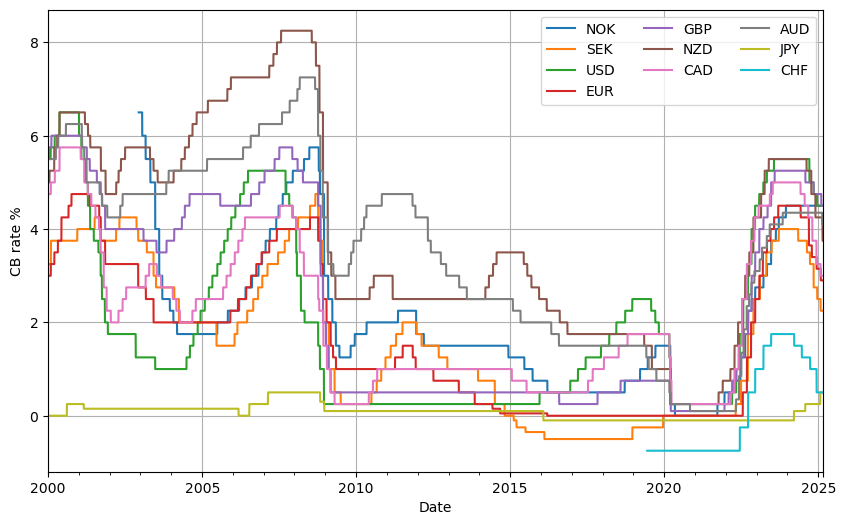

In [17]:
df_cbrate.plot(figsize = (10,6), grid = True, ylabel = 'CB rate %').legend(loc='best', ncols = 3)

## Make CB rate relative to USD and drop USD column

In [18]:
df_cbrate_relative_to_usd = df_cbrate.subtract(df_cbrate['USD'], axis = 0)
df_cbrate_relative_to_usd = df_cbrate_relative_to_usd.drop('USD', axis=1)

## Plot relative CB rates

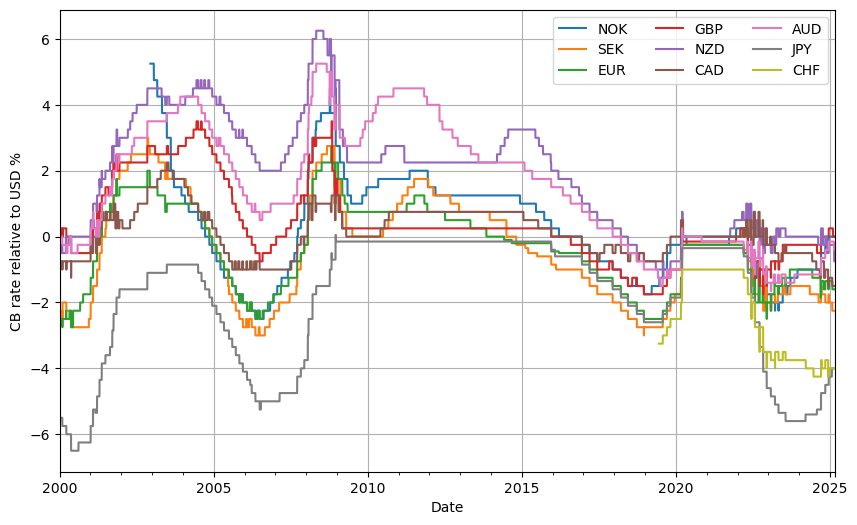

In [19]:
df_cbrate_relative_to_usd.plot(figsize = (10,6), grid = True, ylabel = 'CB rate relative to USD %').legend(loc='best', ncols = 3)

## Lets create in-sample data for model building

In [20]:
signal_insample = df_cbrate_relative_to_usd.loc[:'2022']

##  Now lets backtest this signal

In [21]:
results = aqms.calculate_portfolio_performance(signal_insample, fx_returns, days_lag = 1)

In [22]:
pr = results['portfolio_returns']
pcr = results['portfolio_cum_returns']
acr = results['asset_cum_returns']

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

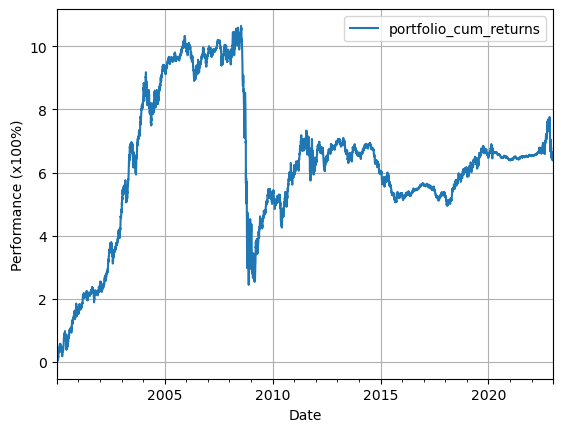

In [23]:
pcr.plot(grid = True, ylabel = 'Performance (x100%)')

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

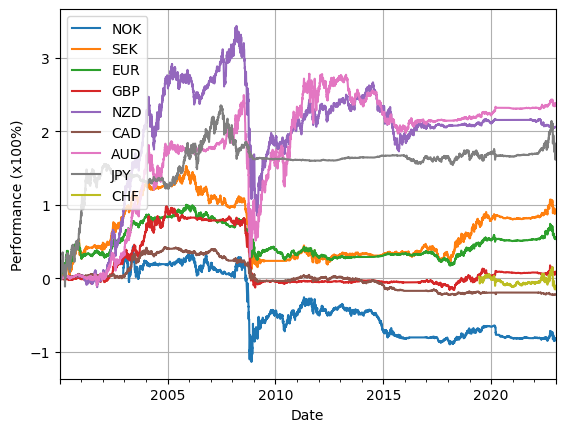

In [24]:
acr.plot(grid = True, ylabel = 'Performance (x100%)')

In [25]:
results['perf_stats']

,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,0.27769,1.212032,0.229111,411.424704,14.129243


## Lets calculate a stacked covariance matrix based on FX returns

In [26]:
my_cov = aqms.calc_stacked_cov(fx_returns, half_life_in_years = 0.5, seed_length_years = 1, return_period_days = 5)

Calculating stacked covariances: 100%|█████████████████████████████████████████████| 6250/6250 [03:42<00:00, 28.14it/s]


In [27]:
my_cov.head()

Date  2001-01-02                                                              \
Asset        EUR       JPY       GBP       AUD       NZD       CAD       CHF   
EUR     0.020058 -0.000396  0.008596  0.011458  0.010643  0.001578  0.016767   
JPY    -0.000396  0.006300 -0.000607  0.000517 -0.000510 -0.000491 -0.000230   
GBP     0.008596 -0.000607  0.008804  0.005133  0.005120  0.001029  0.007490   
AUD     0.011458  0.000517  0.005133  0.014805  0.013921  0.002305  0.009488   
NZD     0.010643 -0.000510  0.005120  0.013921  0.019445  0.002109  0.008955   

Date                      2001-01-03  ... 2024-12-13 2024-12-16            \
Asset       NOK       SEK        EUR  ...        SEK        EUR       JPY   
EUR    0.015831  0.016119   0.019838  ...   0.004129   0.003776  0.003487   
JPY    0.000276  0.000231  -0.000410  ...   0.004902   0.003487  0.013308   
GBP    0.007249  0.008040   0.008504  ...   0.004010   0.003326  0.002682   
AUD    0.009736  0.010386   0.011334  ...   0.004881   0.003115  0.002481   
NZD    0.009065  0.009679   0.010542  ...   0.006028   0.003555  0.004524   

Date                                                                         
Asset       GBP       AUD       NZD       CAD       CHF       NOK       SEK  
EUR    0.003326  0.003115  0.003555  0.001435  0.003077  0.003240  0.004075  
JPY    0.002682  0.002481  0.004524  0.001358  0.005856  0.002262  0.004806  
GBP    0.004603  0.003876  0.004415  0.001692  0.002497  0.003365  0.003953  
AUD    0.003876  0.006890  0.006447  0.003067  0.002237  0.005469  0.004802  
NZD    0.004415  0.006447  0.007977  0.003082  0.003493  0.005752  0.005930  

[5 rows x 56250 columns]

## Calculate the volatility of the portfolio using the risk model and plot it

In [28]:
signal_volatility = aqms.calc_portfolio_vol(df_cbrate_relative_to_usd, my_cov)

<Axes: xlabel='Date', ylabel='Portfolio volatility'>

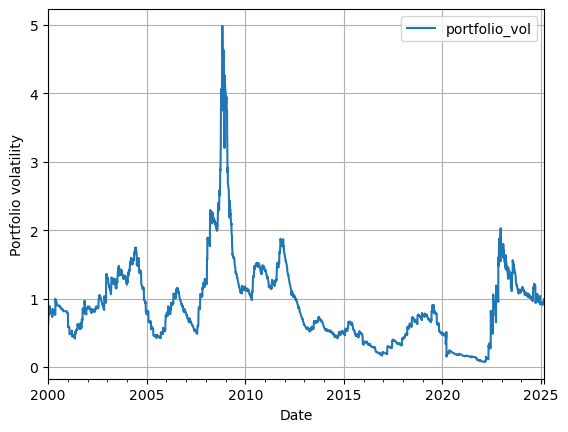

In [29]:
signal_volatility.plot(grid = True, ylabel = 'Portfolio volatility')

## Scale the portfolio to a constant volatility of 1%

In [30]:
signal_insample_normalised, scale_factor = aqms.target_vol(signal_insample, my_cov, volatility = 0.01)

In [31]:
signal_insample_normalised_volatility = aqms.calc_portfolio_vol(signal_insample_normalised, my_cov)

<Axes: xlabel='Date', ylabel='Portfolio volatility'>

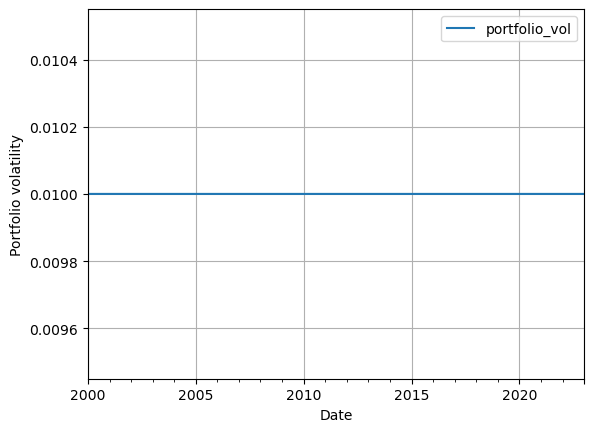

In [32]:
signal_insample_normalised_volatility.plot(grid = True, ylabel = 'Portfolio volatility')

## Calculate performance of the volatility normalised portfolio

In [33]:
results_normalised = aqms.calculate_portfolio_performance(signal_insample_normalised, fx_returns, days_lag = 1)

In [34]:
pr_norm = results_normalised['portfolio_returns']
pcr_norm = results_normalised['portfolio_cum_returns']
acr_norm = results_normalised['asset_cum_returns']

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

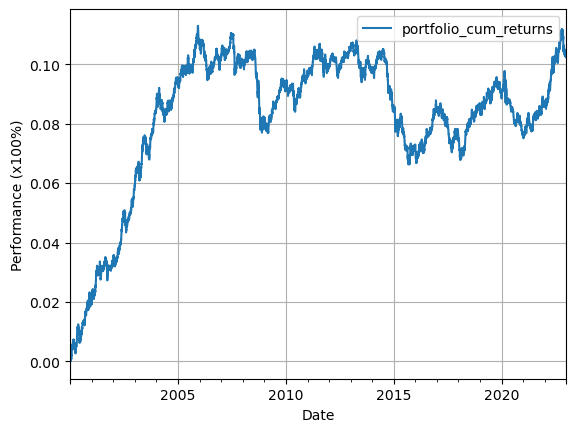

In [35]:
pcr_norm.plot(grid = True, ylabel = 'Performance (x100%)')

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

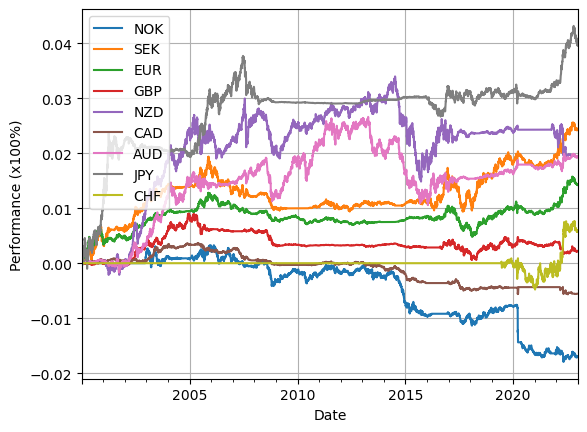

In [36]:
acr_norm.plot(grid = True, ylabel = 'Performance (x100%)')

In [37]:
results_normalised['perf_stats']

,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,0.004449,0.0104,0.427766,175.648159,0.459183


## Let's scale our signal by the volatlity of the asset we are trading (scaling by volatility)

In [38]:
signal_insample_scaled = aqms.scale_by_vol(signal_insample, my_cov)

In [39]:
# We need to normalise the risk again to 1%
signal_insample_scaled_normalised, scale_factor = aqms.target_vol(signal_insample_scaled, my_cov, volatility = 0.01)

In [40]:
results_scaled_normalised = aqms.calculate_portfolio_performance(signal_insample_scaled_normalised, fx_returns, days_lag = 1)

In [41]:
pr_scaeld_norm = results_scaled_normalised['portfolio_returns']
pcr_scaled_norm = results_scaled_normalised['portfolio_cum_returns']
acr_scaled_norm = results_scaled_normalised['asset_cum_returns']

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

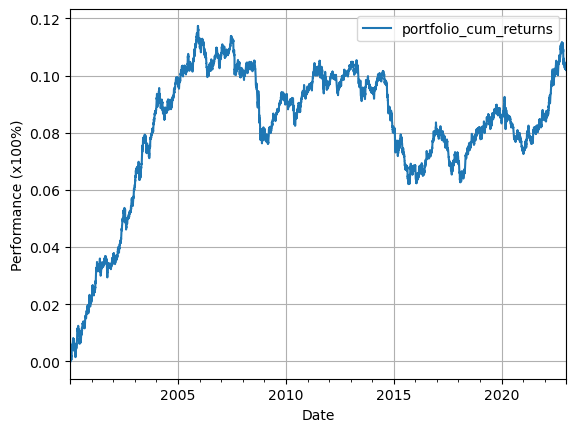

In [42]:
pcr_scaled_norm.plot(grid = True, ylabel = 'Performance (x100%)')

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

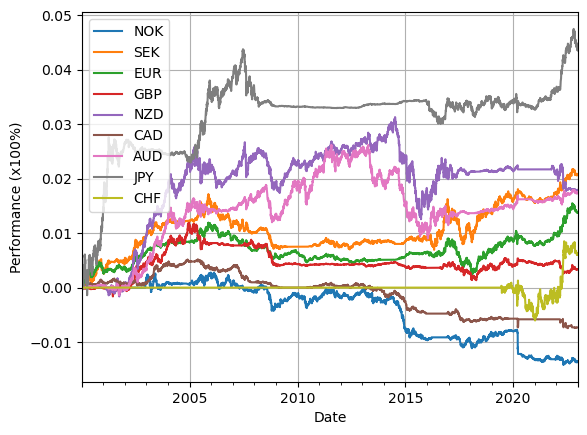

In [43]:
acr_scaled_norm.plot(grid = True, ylabel = 'Performance (x100%)')

In [44]:
results_scaled_normalised['perf_stats']

,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,0.004431,0.010486,0.422542,166.714513,0.500577


## Using the VIX data as a "filter"

In [45]:
# Load the VIX data
vix = pd.read_csv('VIX_History.csv', parse_dates=['DATE'], dayfirst=True)
vix = vix.set_index('DATE')[['CLOSE']]
vix.columns = ['VIX']
vix.index = pd.to_datetime(vix.index)
vix = vix.sort_index()

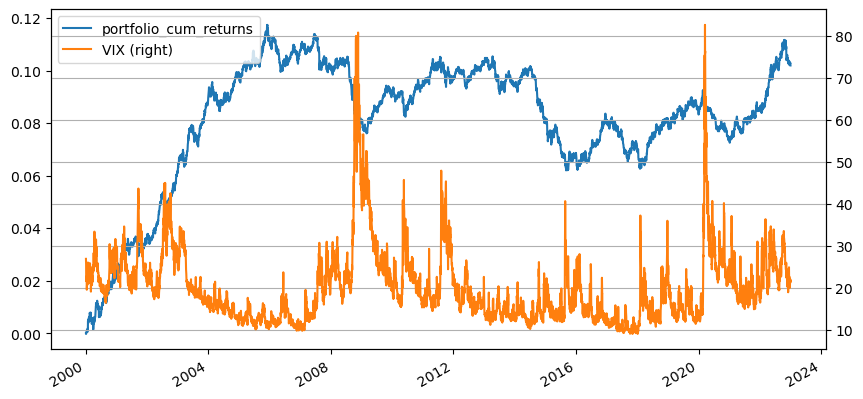

In [46]:
# Graph VIX and performance of model
pp = pd.concat([pcr_scaled_norm, vix], axis = 1).dropna()
ax = pp.plot(secondary_y=['VIX'], figsize = (10,5), grid = True) 
lines, labels = ax.get_legend_handles_labels()           # Primary y-axis
lines2, labels2 = ax.right_ax.get_legend_handles_labels() # Secondary y-axis
# Merge them
ax.legend(lines + lines2, labels + labels2, loc='upper left')

## Visualise how the VIX filter would look for different VIX levels

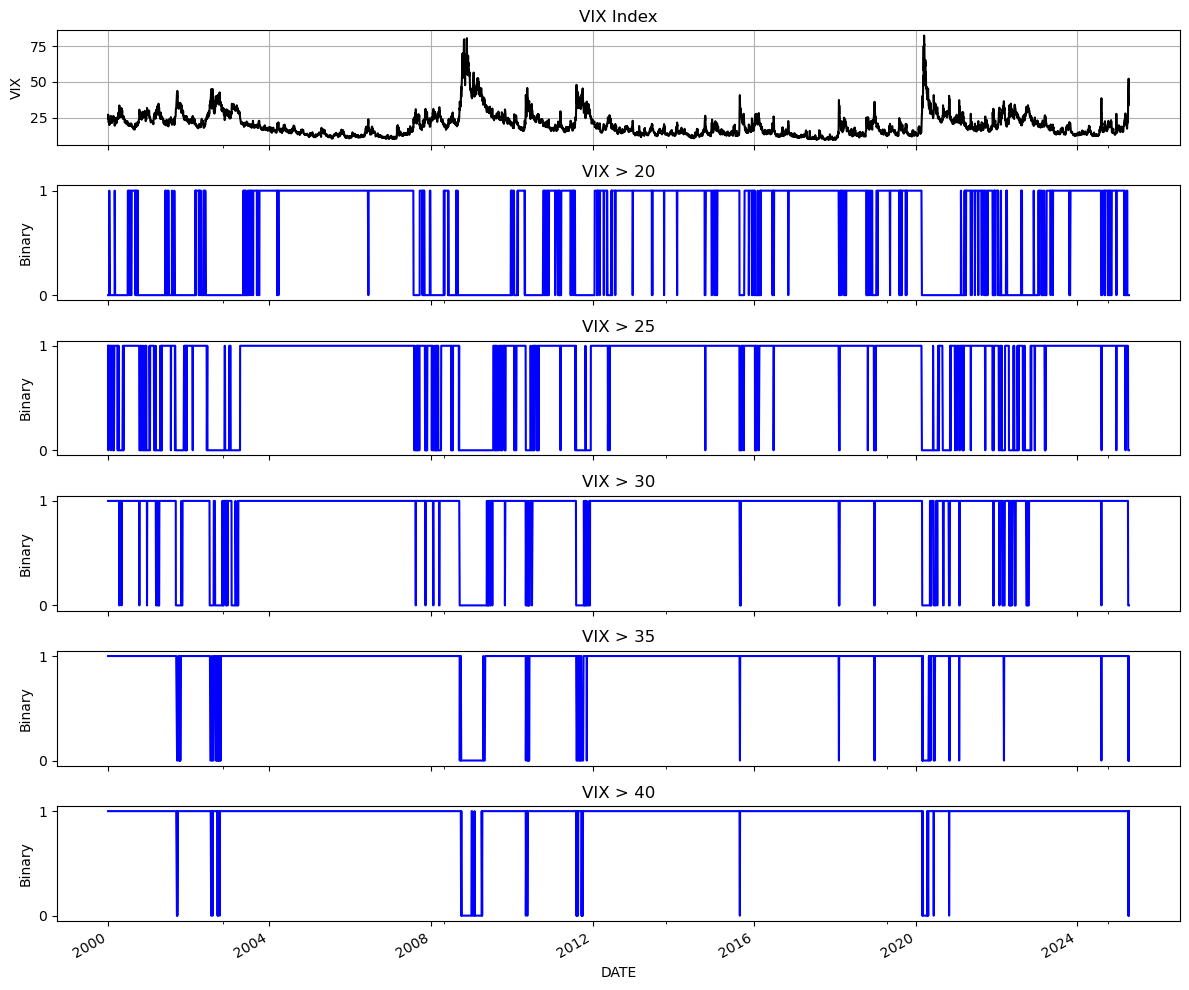

In [47]:
# List of thresholds
levels = [20, 25, 30, 35, 40]

# Make sure vix is a Series (not a DataFrame)
vix_series = vix.loc['2000':].squeeze()  # in case it's a DataFrame with one column

# Create a dict of binary Series (not DataFrames)
binary_series = {f'VIX > {level}': (vix_series < level).astype(int) for level in levels}

# Combine into a DataFrame
binary_df = pd.DataFrame(binary_series)

# Plot
fig, axes = plt.subplots(nrows=len(levels) + 1, ncols=1, figsize=(12, 10), sharex=True)

# Plot original VIX
vix_series.plot(ax=axes[0], title='VIX Index', color='black', grid = True)
axes[0].set_ylabel("VIX")

# Plot each binary series
for i, level in enumerate(levels):
    binary_df[f'VIX > {level}'].plot(ax=axes[i+1], title=f'VIX > {level}', color='blue')
    axes[i+1].set_ylabel("Binary")
    axes[i+1].set_yticks([0, 1])

plt.tight_layout()
plt.show()

## Lets add some smoothing on a preferred risk filter (and also incorporate a NO VIX filter) and run the performance of the model using these filters

In [48]:
binary_df['NO VIX'] = 1
binary_df['VIX > 35 EWMA_1'] = binary_df['VIX > 35'].ewm(halflife=1).mean()
binary_df['VIX > 35 EWMA_3'] = binary_df['VIX > 35'].ewm(halflife=3).mean()
binary_df['VIX > 35 EWMA_5'] = binary_df['VIX > 35'].ewm(halflife=5).mean()

# Create empty dictionary to store results
filtered_results_dict = {}

# Loop over each threshold in binary_df
for column in binary_df.columns:
    # Step 1: Reindex and forward-fill the filter to match signal_insample index
    filter_ = binary_df[column].reindex(signal_insample_scaled_normalised.index).ffill()
    
    # Step 2: Apply filter
    signal_filtered = signal_insample_scaled_normalised.multiply(filter_, axis='index')
    
    # Step 3: Calculate performance
    results_filtered = aqms.calculate_portfolio_performance(signal_filtered, fx_returns, days_lag=1)
    
    # Step 4: Store the results in dictionary
    filtered_results_dict[column] = results_filtered

In [49]:
# Create an empty list to store all performance rows
perf_stats_list = []

# Loop through each filter level
for filter_level, results in filtered_results_dict.items():
    # Extract perf_stats dataframe (assuming it's always one row)
    perf_stats_row = results['perf_stats'].copy()
    # Add a column to identify the filter
    perf_stats_row['Filter Level'] = filter_level
    # Append to list
    perf_stats_list.append(perf_stats_row)

# Concatenate all rows into one dataframe
perf_stats_summary = pd.concat(perf_stats_list, ignore_index=True)

# Optional: Move 'Filter Level' to first column
cols = ['Filter Level'] + [col for col in perf_stats_summary.columns if col != 'Filter Level']
perf_stats_summary = perf_stats_summary[cols]

# Now you have a nice dataframe:
perf_stats_summary

,Filter Level,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,VIX > 20,0.002465,0.007553,0.326327,23.727469,2.247295
1,VIX > 25,0.002858,0.008869,0.322182,36.410032,1.880682
2,VIX > 30,0.004676,0.009629,0.485581,57.913401,1.324341
3,VIX > 35,0.005010,0.010025,0.499797,87.553581,0.922567
4,VIX > 40,0.004870,0.010145,0.480016,110.713966,0.741505
5,NO VIX,0.004431,0.010486,0.422542,166.714513,0.500577
6,VIX > 35 EWMA_1,0.004782,0.009993,0.478475,108.510341,0.744610
7,VIX > 35 EWMA_3,0.004626,0.009986,0.463267,132.694677,0.609211
8,VIX > 35 EWMA_5,0.004533,0.009996,0.453443,142.572469,0.567193


## Lets choose the VIX>35 as our preferred filter and apply to our final model build

In [50]:
# Apply filter to our signal
filter = binary_df['VIX > 35'].reindex(signal_insample_scaled_normalised.index).ffill()
signal_insample_scaled_normalised_filtered = signal_insample_scaled_normalised.multiply(filter, axis = 'index')
results_filtered = aqms.calculate_portfolio_performance(signal_insample_scaled_normalised_filtered, fx_returns, days_lag = 1)

In [51]:
pr_filtered = results_filtered['portfolio_returns']
pcr_filtered = results_filtered['portfolio_cum_returns']
acr_filtered = results_filtered['asset_cum_returns']

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

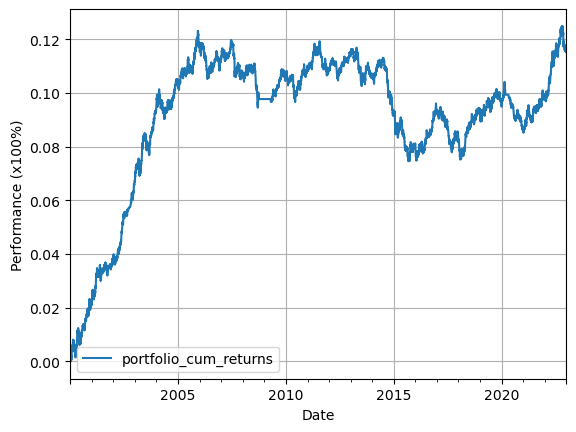

In [52]:
pcr_filtered.plot(grid = True, ylabel = 'Performance (x100%)')

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

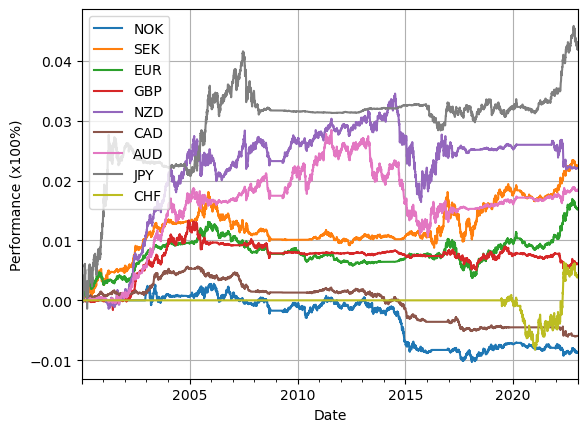

In [53]:
acr_filtered.plot(grid = True, ylabel = 'Performance (x100%)')

In [54]:
results_filtered['perf_stats']

,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,0.00501,0.010025,0.499797,87.553581,0.922567


## Calculate lead/lag IRs

In [59]:
lead_lag = aqmsx.calc_lead_lag_IR(signal_insample_scaled_normalised_filtered, fx_returns, range(-20,21))

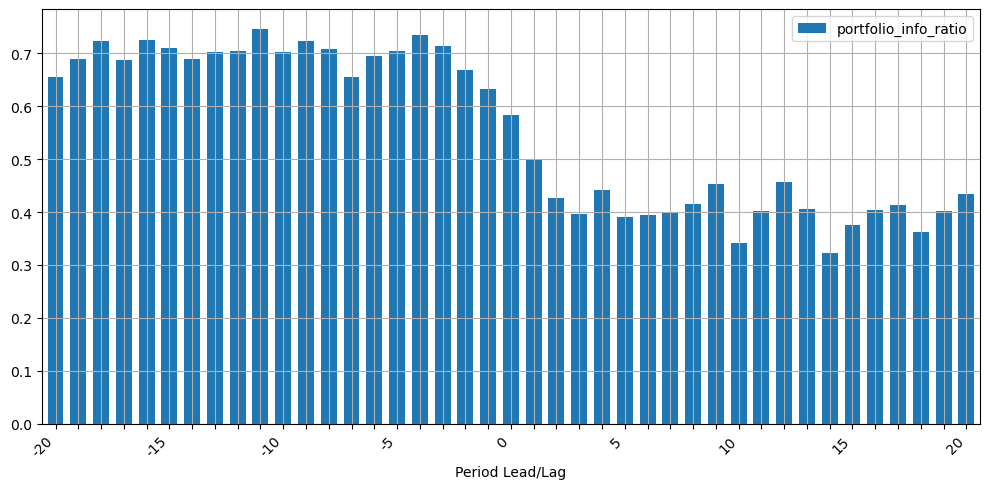

In [60]:
# Plot the IRs by lead/lag
import matplotlib.pyplot as plt
import numpy as np

ax = lead_lag.plot.bar(grid=True, width=0.7, figsize=(10,5))
ax.set_xlabel('Period Lead/Lag')

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Limit number of x-ticks: show every Nth tick only
N = 5  # Show every 5th label (adjust N depending on how crowded)
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % N != 0:
        label.set_visible(False)

# Adjust layout
plt.tight_layout()

## Do Jackknife tests

In [62]:
contrib_IR = aqmsx.calc_contribution_to_IR(signal_insample_scaled_normalised_filtered, fx_returns, my_cov)

<Axes: xlabel='Asset'>

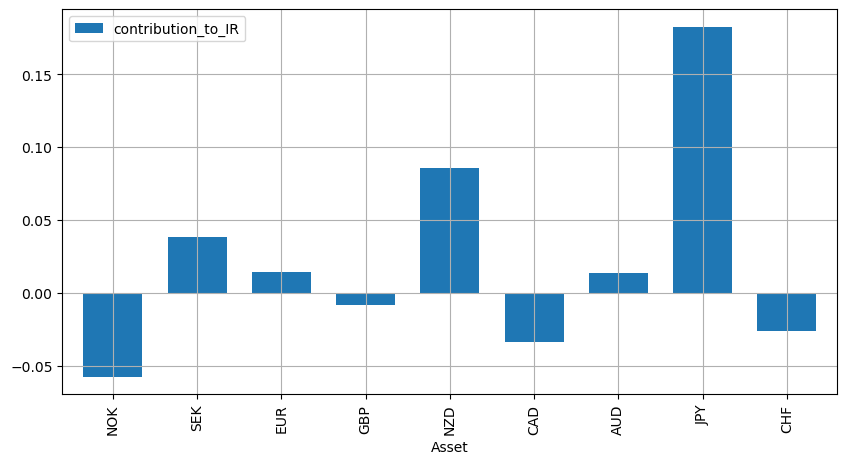

In [63]:
contrib_IR.plot.bar(grid = True, width=0.7, figsize = (10,5), xlabel = 'Asset')

## Open the out of sample window

In [65]:
# lets do the full sample back test
signal_fullsample = df_cbrate_relative_to_usd
signal_fullsample_scaled = aqms.scale_by_vol(signal_fullsample, my_cov)
signal_fullsample_scaled_normalised, sf = aqms.target_vol(signal_fullsample_scaled, my_cov, volatility = 0.01)
filter_full = binary_df['VIX > 35'].reindex(signal_fullsample_scaled_normalised.index).ffill()
signal_fullsample_scaled_normalised_filtered = signal_fullsample_scaled_normalised.multiply(filter_full, axis = 'index')
results_full_filtered = aqms.calculate_portfolio_performance(signal_fullsample_scaled_normalised_filtered, fx_returns, days_lag = 1)

In [66]:
pr_full_filtered = results_full_filtered['portfolio_returns']
pcr_full_filtered = results_full_filtered['portfolio_cum_returns']
acr_full_filtered = results_full_filtered['asset_cum_returns']

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

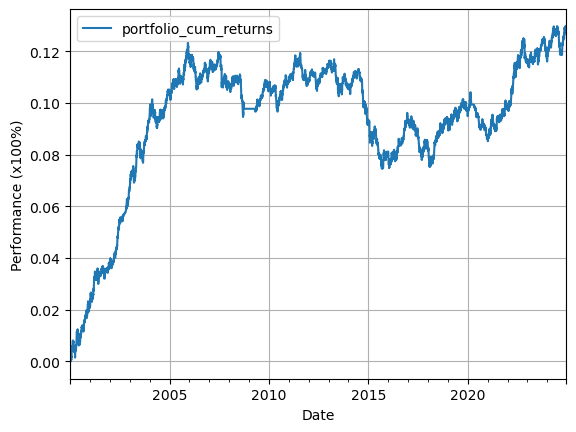

In [67]:
pcr_full_filtered.plot(grid = True, ylabel = 'Performance (x100%)')

<Axes: xlabel='Date', ylabel='Performance (x100%)'>

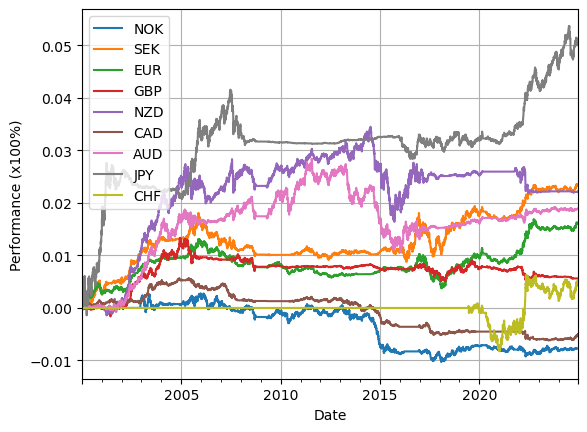

In [68]:
acr_full_filtered.plot(grid = True, ylabel = 'Performance (x100%)')

In [69]:
results_full_filtered['perf_stats']

,portfolio_ann_return Return,portfolio_ann_std,portfolio_info_ratio,holding_period,turnover
0,0.005199,0.009994,0.520192,89.643741,0.892602


In [70]:
# setup dataframes for the insample and full sample portfolios
df_insample = pr_filtered
df_all = pr_full_filtered

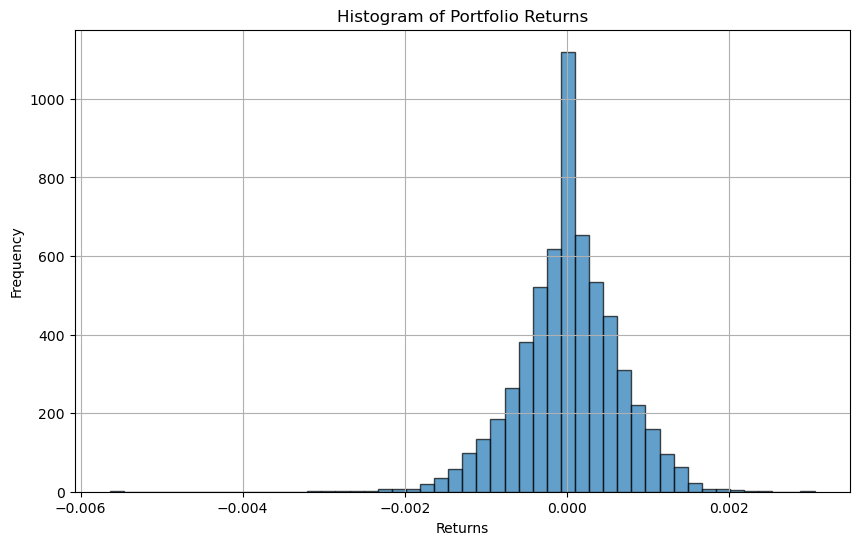

In [71]:
# Histogram of insample returns
plt.figure(figsize=(10, 6))
plt.hist(df_insample['portfolio_returns'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Histogram of Portfolio Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Plot out-of-sample returns over bootstapped in-sample returns

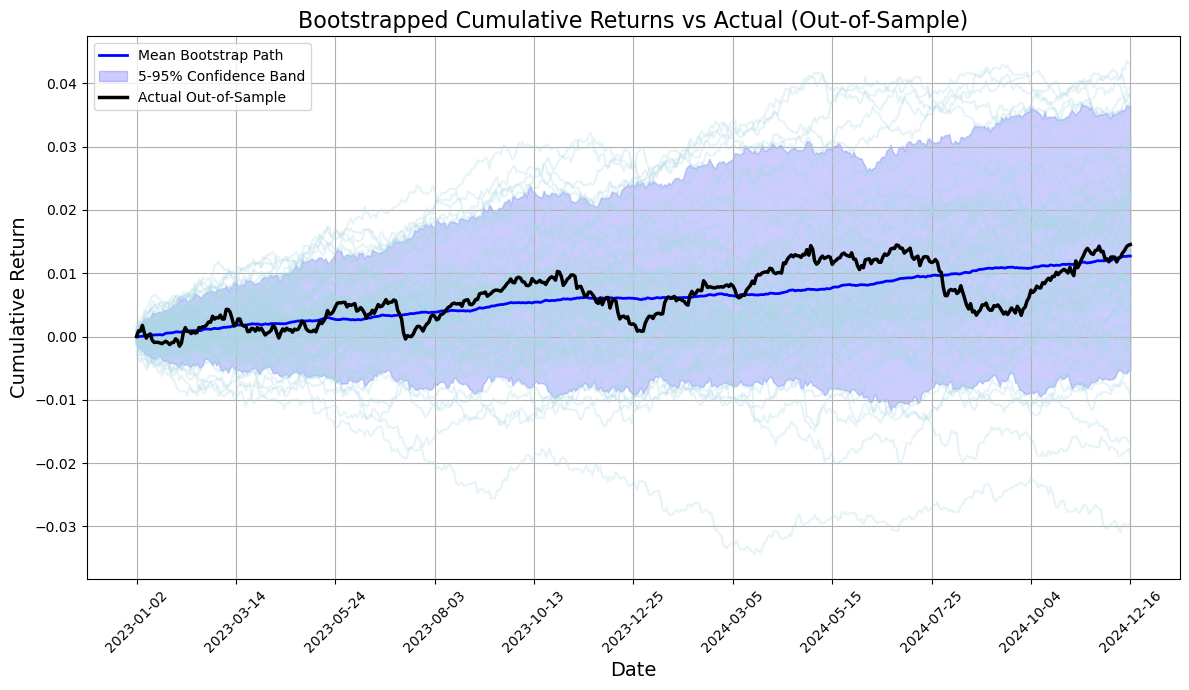

In [76]:
aqmsx.plot_bootstrapped_rtns(df_insample, df_all, 100)

## Plot performance relative to IR = 0.5 strategy. Show confidence intervals.

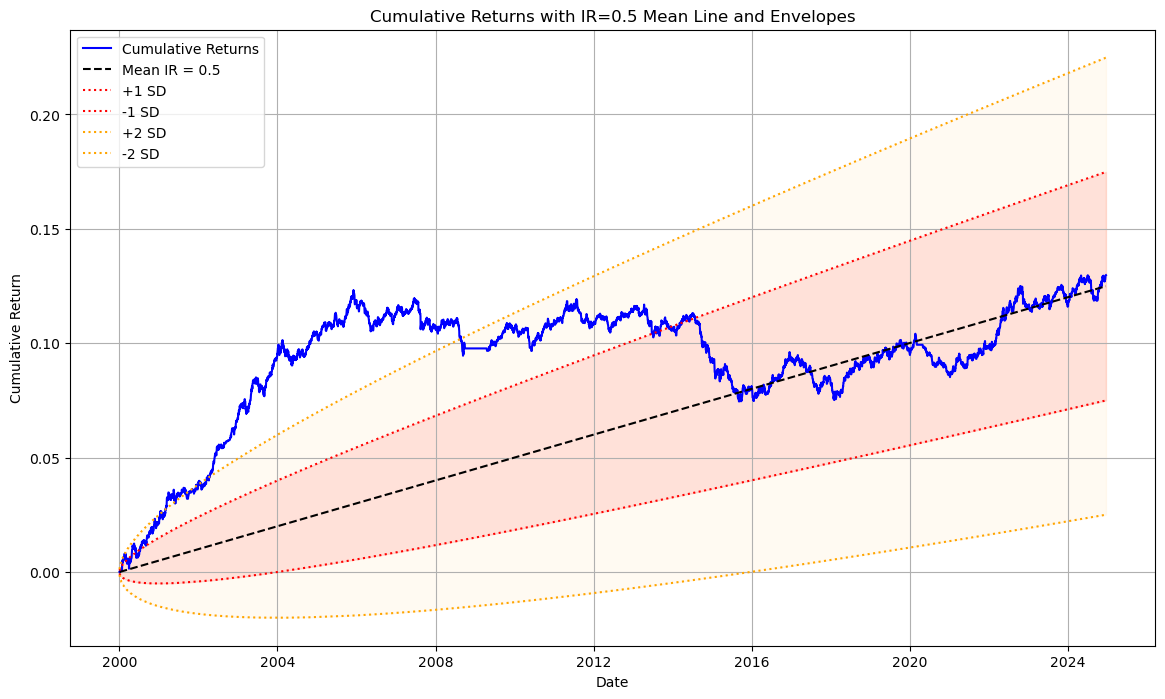

In [77]:
aqmsx.plot_cumsum_with_ir_bounds(pr_full_filtered, periods_per_year=260, target_ir=0.5)